# Messages per User

Visualization of message counts per user (anonymized with hashed identifiers), for full IA data and IA filtered to the NWA date span.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from matplotlib.ticker import FuncFormatter
from usenet_no.notebook_utils import venn2_fmt

space_fmt = FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", " "))

In [2]:
def load_user_counts(path):
    df = pd.read_csv(path)
    return df.sort_values("post_count", ascending=False)


ia_full = load_user_counts("../data/messages_per_user_ia.csv")
ia_filtered = load_user_counts("../data/messages_per_user_ia_date_filtered.csv")
df_nwa = load_user_counts("../data/messages_per_user_nwa.csv")


def print_stats(df, label):
    print(f"{label}")
    print(f"  Total unique users: {len(df):,}")
    print(f"  Total posts:        {df['post_count'].sum():,}")
    print(f"  Users with name:    {df['hashed_name'].notna().sum():,}")
    print(f"  Users with email:   {df['hashed_email'].notna().sum():,}")


for label, df_ia in [("Full IA", ia_full), ("IA date-filtered", ia_filtered)]:
    print_stats(df_ia, label)
    nwa_pct = df_nwa["post_count"].sum() / df_ia["post_count"].sum() * 100
    print(f"  NWA is {nwa_pct:.1f}% the size by post count")
    print()
print_stats(df_nwa, "NWA")

Full IA
  Total unique users: 238,702
  Total posts:        5,985,245
  Users with name:    189,100
  Users with email:   238,653
  NWA is 10.3% the size by post count

IA date-filtered
  Total unique users: 50,613
  Total posts:        575,768
  Users with name:    30,779
  Users with email:   50,610
  NWA is 106.6% the size by post count

NWA
  Total unique users: 49,856
  Total posts:        613,626
  Users with name:    27,831
  Users with email:   49,850


# Post counts for top 20 posters

In [3]:
n = 20
for label, df_ia in [("Full IA", ia_full), ("IA date-filtered", ia_filtered)]:
    print(f"\nTop {n} posters — {label}")
    print(df_ia.head(n).reset_index().post_count.apply(space_fmt))


Top 20 posters — Full IA
0     44 030
1     28 817
2     26 271
3     22 906
4     20 663
5     18 468
6     17 374
7     16 239
8     15 432
9     14 229
10    14 176
11    13 848
12    13 403
13    13 172
14    12 920
15    12 577
16    12 238
17    11 885
18    11 640
19    11 036
Name: post_count, dtype: str

Top 20 posters — IA date-filtered
0     5 486
1     4 762
2     4 038
3     2 652
4     2 228
5     2 200
6     2 011
7     1 915
8     1 862
9     1 751
10    1 663
11    1 610
12    1 605
13    1 505
14    1 498
15    1 411
16    1 389
17    1 202
18    1 140
19    1 138
Name: post_count, dtype: str


In [4]:
print(f"Number of posts by top {n} posters in Norwegian Web Archive data")
print(df_nwa.head(n).reset_index().post_count.apply(space_fmt))

Number of posts by top 20 posters in Norwegian Web Archive data
0     5 612
1     4 349
2     3 784
3     2 975
4     2 451
5     2 410
6     2 387
7     2 384
8     1 947
9     1 920
10    1 888
11    1 731
12    1 673
13    1 652
14    1 607
15    1 464
16    1 416
17    1 389
18    1 389
19    1 343
Name: post_count, dtype: str


# Plot top n vs rest

In [5]:
def plot_top_vs_rest(df, n, title):
    top_sum = df.head(n)["post_count"].sum()
    rest_sum = df.iloc[n:]["post_count"].sum()
    rest_label = f"Rest ({len(df) - n:,} users)".replace(",", " ")
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.bar([f"Top {n} users", rest_label], [top_sum, rest_sum])
    ax.yaxis.set_major_formatter(space_fmt)
    for i, v in enumerate([top_sum, rest_sum]):
        ax.text(i, v, f"{v:,}".replace(",", " "), ha="center", va="bottom", fontsize=10)
    ax.set_ylabel("Total Posts")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

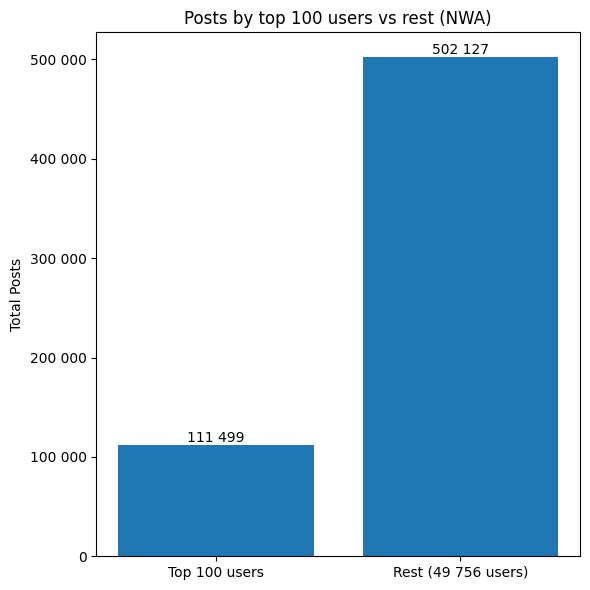

In [6]:
n = 100

plot_top_vs_rest(df_nwa, n, f"Posts by top {n} users vs rest (NWA)")

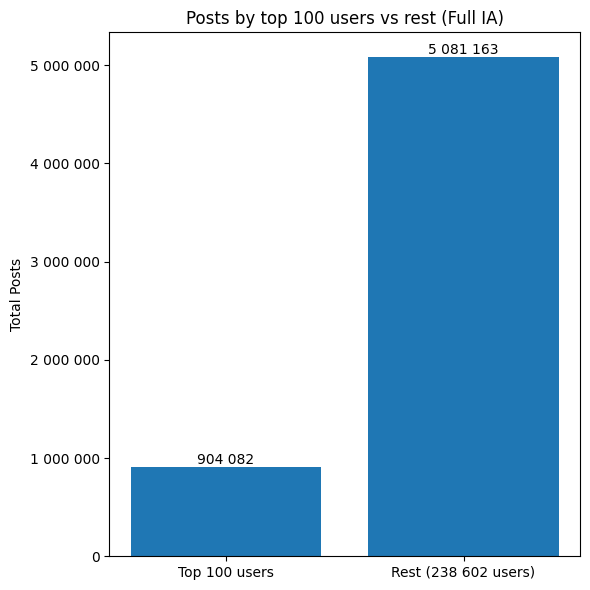

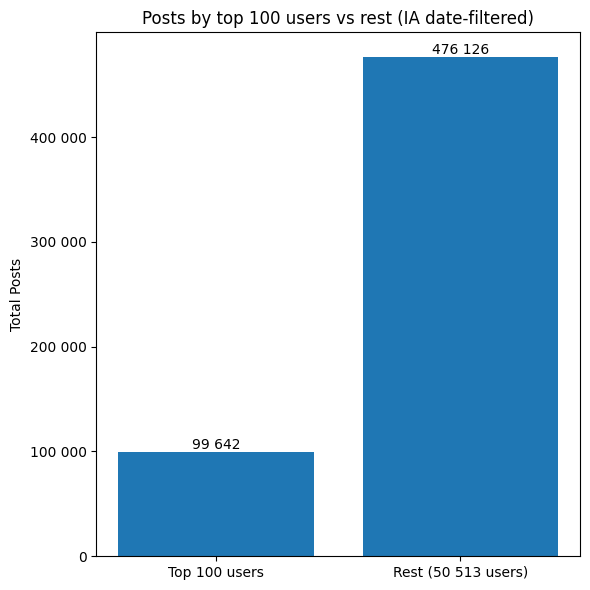

In [7]:
n = 100
for label, df_ia in [("Full IA", ia_full), ("IA date-filtered", ia_filtered)]:
    plot_top_vs_rest(df_ia, n, f"Posts by top {n} users vs rest ({label})")

# Cumulative distribution

In [8]:
fig = go.Figure()

for df, label in [
    (ia_full, "Full IA"),
    (ia_filtered, "IA date-filtered"),
    (df_nwa, "NWA"),
]:
    df_sorted = df.sort_values("post_count", ascending=False).reset_index(drop=True)
    df_sorted["cumulative_pct"] = (
        df_sorted["post_count"].cumsum() / df_sorted["post_count"].sum() * 100
    )
    fig.add_trace(
        go.Scatter(
            x=df_sorted.index + 1,
            y=df_sorted["cumulative_pct"],
            mode="lines",
            name=label,
        )
    )

fig.add_hline(y=50, line_dash="dash", line_color="red", annotation_text="50%")
fig.add_hline(y=80, line_dash="dash", line_color="green", annotation_text="80%")
fig.update_layout(
    title="Cumulative post distribution by user",
    xaxis_title="Number of top users",
    yaxis_title="Cumulative % of all posts",
)
fig.show()

In [9]:
for df, label in [
    (ia_full, "Full IA"),
    (ia_filtered, "IA date-filtered"),
    (df_nwa, "NWA"),
]:
    df_sorted = df.sort_values("post_count", ascending=False).reset_index(drop=True)
    df_sorted["cumulative_pct"] = (
        df_sorted["post_count"].cumsum() / df_sorted["post_count"].sum() * 100
    )
    n = len(df_sorted)
    users_50 = (df_sorted["cumulative_pct"] >= 50).idxmax() + 1
    users_80 = (df_sorted["cumulative_pct"] >= 80).idxmax() + 1
    print(
        f"{label}: top {users_50:,} users ({users_50 / n * 100:.2f}%) account for 50% of posts"
    )
    print(
        f"{label}: top {users_80:,} users ({users_80 / n * 100:.2f}%) account for 80% of posts"
    )
    print()

Full IA: top 1,876 users (0.79%) account for 50% of posts
Full IA: top 15,149 users (6.35%) account for 80% of posts

IA date-filtered: top 1,091 users (2.16%) account for 50% of posts
IA date-filtered: top 7,052 users (13.93%) account for 80% of posts

NWA: top 976 users (1.96%) account for 50% of posts
NWA: top 6,454 users (12.95%) account for 80% of posts



# Users in both sources

In [10]:
nwa_by_email = df_nwa.groupby("hashed_email")["post_count"].sum().reset_index()
total_nwa = df_nwa["post_count"].sum()
n = 10


def display_top_shared(shared, total_ia, sort_col, sort_label):
    result = (
        shared.sort_values(sort_col, ascending=False)
        .head(n)
        .reset_index(drop=True)
        .copy()
    )
    result["pct_ia"] = (result["post_count_ia"] / total_ia * 100).map("{:.2f}%".format)
    result["pct_nwa"] = (result["post_count_nwa"] / total_nwa * 100).map(
        "{:.2f}%".format
    )
    print(f"Top {n} shared users by {sort_label} post count")
    return result[["hashed_email", "pct_ia", "pct_nwa"]]


for label, df_ia in [("Full IA", ia_full), ("IA date-filtered", ia_filtered)]:
    ia_by_email = df_ia.groupby("hashed_email")["post_count"].sum().reset_index()
    shared = ia_by_email.merge(
        nwa_by_email, on="hashed_email", suffixes=("_ia", "_nwa")
    )
    total_ia = df_ia["post_count"].sum()

    print(f"\n{label}")
    print(f"Users in both IA and NWA (by email): {len(shared):,}")
    print(
        f"  IA-only users:  {len(ia_by_email[~ia_by_email['hashed_email'].isin(shared['hashed_email'])]):,}"
    )
    print(
        f"  NWA-only users: {len(nwa_by_email[~nwa_by_email['hashed_email'].isin(shared['hashed_email'])]):,}"
    )
    display(display_top_shared(shared, total_ia, "post_count_ia", "IA"))
    display(display_top_shared(shared, total_ia, "post_count_nwa", "NWA"))


Full IA
Users in both IA and NWA (by email): 33,870
  IA-only users:  158,830
  NWA-only users: 9,523
Top 10 shared users by IA post count


,hashed_email,pct_ia,pct_nwa
0,898187efc071f23b,0.44%,0.96%
1,cd0e87f8c5d05016,0.38%,0.05%
2,58c767fc11c3bf5d,0.24%,0.00%
3,5594d57a7e195faf,0.23%,0.05%
4,d5cc45a6bf11c68e,0.23%,0.07%
5,b3084aad6cc7b8c5,0.20%,0.04%
6,a6e8ab38ffcba15b,0.18%,0.02%
7,898828d5347cfc54,0.17%,0.23%
8,46d85e20e54b9956,0.15%,0.03%
9,1b03ca37d7116296,0.15%,0.05%


Top 10 shared users by NWA post count


,hashed_email,pct_ia,pct_nwa
0,898187efc071f23b,0.44%,0.96%
1,c3dd03f2a3ffd6de,0.10%,0.71%
2,8cb56259d88bffd8,0.00%,0.62%
3,d3ae2e2c5ecdd415,0.03%,0.48%
4,30d0be1ae12a7749,0.03%,0.40%
5,ad36d72860ab5776,0.07%,0.40%
6,f23e5a24dc97cafb,0.03%,0.39%
7,c06828244a65f48d,0.03%,0.39%
8,e2a7e62962e3a785,0.03%,0.34%
9,41e8a2368fb19b57,0.05%,0.32%



IA date-filtered
Users in both IA and NWA (by email): 33,365
  IA-only users:  10,254
  NWA-only users: 10,028
Top 10 shared users by IA post count


,hashed_email,pct_ia,pct_nwa
0,43f472e23049c6ec,0.95%,0.10%
1,c3dd03f2a3ffd6de,0.83%,0.71%
2,898187efc071f23b,0.70%,0.96%
3,ad36d72860ab5776,0.46%,0.40%
4,d8c51a7108bd2bc0,0.39%,0.31%
5,6d164a4184e3faa8,0.38%,0.28%
6,b3affbc7a5aa8246,0.37%,0.30%
7,c06828244a65f48d,0.35%,0.39%
8,30d0be1ae12a7749,0.33%,0.40%
9,41e8a2368fb19b57,0.33%,0.32%


Top 10 shared users by NWA post count


,hashed_email,pct_ia,pct_nwa
0,898187efc071f23b,0.70%,0.96%
1,c3dd03f2a3ffd6de,0.83%,0.71%
2,d3ae2e2c5ecdd415,0.02%,0.48%
3,30d0be1ae12a7749,0.33%,0.40%
4,ad36d72860ab5776,0.46%,0.40%
5,f23e5a24dc97cafb,0.25%,0.39%
6,c06828244a65f48d,0.35%,0.39%
7,e2a7e62962e3a785,0.31%,0.34%
8,41e8a2368fb19b57,0.33%,0.32%
9,d8c51a7108bd2bc0,0.39%,0.31%


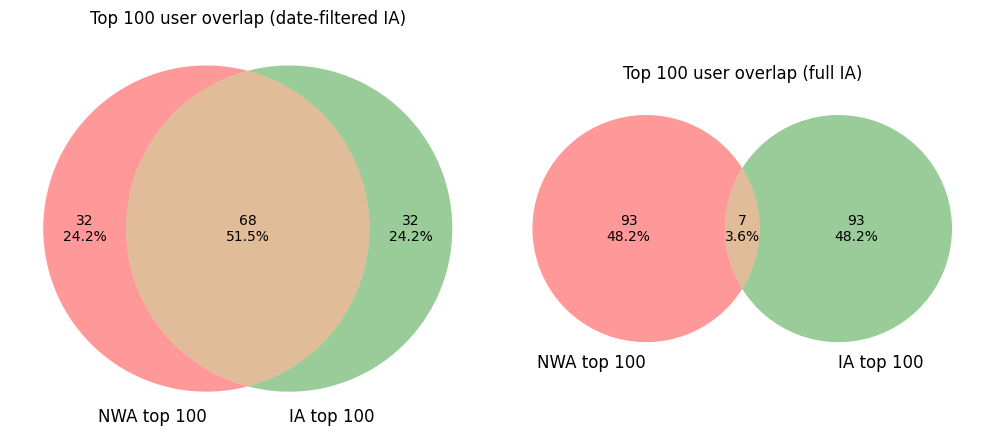

In [11]:
top_n = 100
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, (label, df_ia) in zip(
    axes, [("date-filtered IA", ia_filtered), ("full IA", ia_full)]
):
    ia_by_email_local = df_ia.groupby("hashed_email")["post_count"].sum().reset_index()
    top_ia = set(ia_by_email_local.nlargest(top_n, "post_count")["hashed_email"])
    top_nwa = set(nwa_by_email.nlargest(top_n, "post_count")["hashed_email"])
    venn2_fmt(
        [top_nwa, top_ia],
        set_labels=(f"NWA top {top_n}", f"IA top {top_n}"),
        ax=ax,
        show_pct=True,
    )
    ax.set_title(f"Top {top_n} user overlap ({label})")
plt.tight_layout()
plt.show()

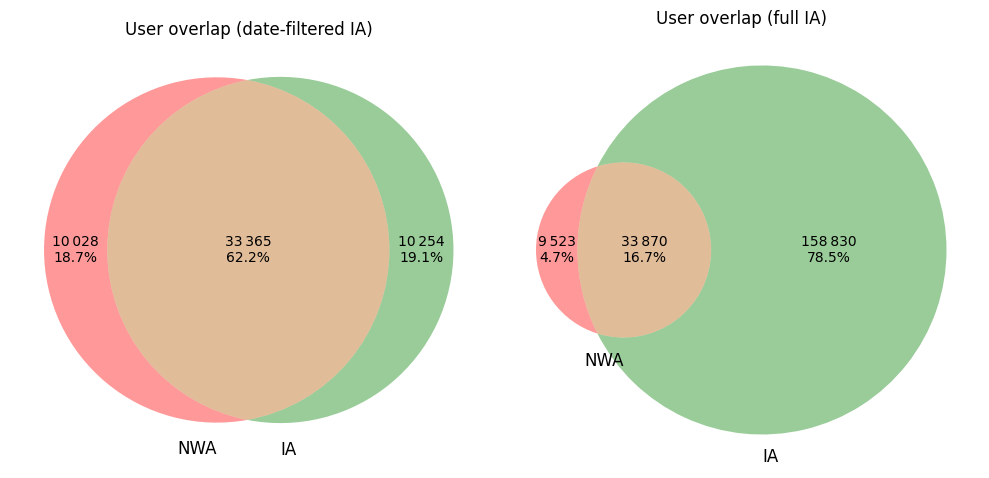

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, (label, df_ia) in zip(
    axes, [("date-filtered IA", ia_filtered), ("full IA", ia_full)]
):
    ia_by_email_local = df_ia.groupby("hashed_email")["post_count"].sum().reset_index()
    all_ia = set(ia_by_email_local["hashed_email"].dropna())
    all_nwa = set(nwa_by_email["hashed_email"].dropna())
    venn2_fmt([all_nwa, all_ia], set_labels=("NWA", "IA"), ax=ax, show_pct=True)
    ax.set_title(f"User overlap ({label})")
plt.tight_layout()
plt.show()